In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("results-sisap25.csv")
df

,team,algo,task,k,recall,buildtime,querytime,params,begins,ends,total_time,throughput
0,ABS-BLINE,ABS,task1,30,0.463140,4.320263e+03,0.545874,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...,2025-06-21T00:14:01.0,2025-06-21T01:31:48.0,4667.0,18319.253653
1,ABS-BLINE,ABS,task1,30,0.531753,4.320263e+03,0.514446,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...,2025-06-21T00:14:01.0,2025-06-21T01:31:48.0,4667.0,19438.379913
2,ABS-BLINE,ABS,task1,30,0.592343,4.320263e+03,0.476158,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...,2025-06-21T00:14:01.0,2025-06-21T01:31:48.0,4667.0,21001.419683
3,ABS-BLINE,ABS,task1,30,0.646520,4.320263e+03,0.494520,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...,2025-06-21T00:14:01.0,2025-06-21T01:31:48.0,4667.0,20221.631508
4,ABS-BLINE,ABS,task1,30,0.692360,4.320263e+03,0.524358,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...,2025-06-21T00:14:01.0,2025-06-21T01:31:48.0,4667.0,19070.934809
...,...,...,...,...,...,...,...,...,...,...,...,...
67,BrownCICESE,BrownCICESE,task1,30,0.961393,9.562970e+03,10.050978,"index=(BrownCICESE),query=(b=500)",2025-06-14T15:43:35.0,2025-06-14T18:24:21.0,9646.0,994.928061
68,BrownCICESE,BrownCICESE,task1,30,0.971290,9.562970e+03,17.951509,"index=(BrownCICESE),query=(b=1000)",2025-06-14T15:43:35.0,2025-06-14T18:24:21.0,9646.0,557.056227
69,BrownCICESE,BrownCICESE,task2,15,0.819839,9.080475e+00,437.450753,"index=(BrownCICESE),query=(M=52,H=26,O=100000,...",2025-06-15T21:31:50.0,2025-06-15T21:39:20.0,450.0,22.859716
70,JLapeyra,NaN,task1,30,0.999980,1.000000e+09,870.322957,"{""d_pca"": null, ""k_search"": 200, ""no_self_loop...",2025-06-22T04:17:22.0,2025-06-22T04:31:55.0,873.0,11.489988


In [3]:
df.team.unique()

array(['ABS-BLINE', 'DCC-UChile', 'TeamDoubleFiltering', 'MetricSearch',
       'hforest', 'cc-lll', 'BrownCICESE', 'JLapeyra'], dtype=object)

# Task 1

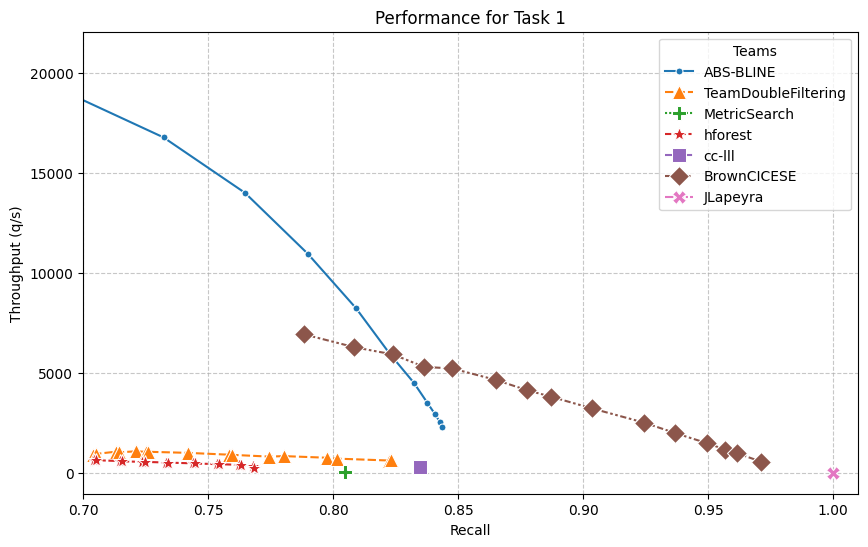

In [4]:
plt.figure(figsize=(10, 6))
#task1 = df[df.task == 'task1']
task1 = df.query("task == 'task1'")
M = {
    'ABS-BLINE' : '.',
    'DCC-UChile' : 'v',
    'TeamDoubleFiltering': '^',
    'MetricSearch': 'P',
    'hforest': '*',
    'cc-lll': 's',
    'BrownCICESE': 'D',
    'JLapeyra': 'X'
}

#sns.scatterplot(x='recall', y='throughput', hue='team', style='team', markers=True, s=70, data=task1)
sns.lineplot(x='recall', y='throughput', hue='team', style='team', markers=M, markersize=10, data=task1)
#sns.lineplot(x='recall', y='throughput', hue='team', data=task1)

plt.title('Performance for Task 1')
plt.xlabel('Recall')
plt.ylabel('Throughput (q/s)')
plt.xlim(((0.7, 1.01)))
plt.legend(title='Teams')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("fig-task1.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
R = {
    'team': [],
    'k': [],
    'recall': [],
    'buildtime': [],
    'querytime': [],
    'throughput': [],
    'total_time': [],
    'params': [],

}

for name, g in task1.groupby(by='team'):
    if len(g.team) == 0:
        continue

    G = g.query("recall >= 0.8")
    if len(G.throughput) > 0:
        m = G.throughput.argmax()
        G = G.iloc[m]
    else:
        m = g.recall.argmax()
        G = g.iloc[m]        
    
    R['team'].append(G.team)
    R['k'].append(G.k)
    R['recall'].append(G.recall)
    R['buildtime'].append(G.buildtime)
    R['querytime'].append(G.querytime)
    R['throughput'].append(G.throughput)
    R['params'].append(G.params)
    R['total_time'].append(G.total_time)
        

R = pd.DataFrame(R)
#print(R.to_latex(float_format="%.4f"))
L = R.to_latex(index=False, formatters={
    "recall": lambda x: f"{x:.4f}",
    "buildtime": lambda x: f"{x:.0f}s",
    "querytime": lambda x: f"{x:.0f}s",
    "total_time": lambda x: f"{x:.0f}s",
    "throughput": lambda x: f"{x:.0f} q/s",
    })

display(R)
print(L)


,team,k,recall,buildtime,querytime,throughput,total_time,params
0,ABS-BLINE,30,0.809093,4.320263e+03,1.213364,8241.551875,4667.0,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...
1,BrownCICESE,30,0.808460,9.562970e+03,1.591339,6284.017608,9646.0,"index=(BrownCICESE),query=(b=35)"
2,JLapeyra,30,0.999980,1.000000e+09,870.322957,11.489988,873.0,"{""d_pca"": null, ""k_search"": 200, ""no_self_loop..."
3,MetricSearch,30,0.804770,2.980000e+03,178.000000,56.179775,3161.0,NaN
4,TeamDoubleFiltering,30,0.801653,3.240000e+02,13.985000,715.051841,324.0,"[20,1,""RAM"",250000,1000]"
5,cc-lll,30,0.834700,6.418762e+03,34.605410,288.972159,6457.0,"{'R': '64', 'LB': '100', 'B': '3', 'M': '4', '..."
6,hforest,30,0.768420,2.243136e+03,42.859111,233.322619,2594.0,"index=(ntrees=160,leaf_size=100),query=(ntrees..."


\begin{tabular}{lrrrrrrl}
\toprule
team & k & recall & buildtime & querytime & throughput & total_time & params \\
\midrule
ABS-BLINE & 30 & 0.8091 & 4320s & 1s & 8242 q/s & 4667s & pca-i8 192; MinRecall 0.97 ; Neighborhood{SatNeighborhood} logbase 1.3 minsize Int32 2 filter SatNeighborhood \\
BrownCICESE & 30 & 0.8085 & 9563s & 2s & 6284 q/s & 9646s & index=(BrownCICESE),query=(b=35) \\
JLapeyra & 30 & 1.0000 & 1000000000s & 870s & 11 q/s & 873s & {"d_pca": null, "k_search": 200, "no_self_loops": false} \\
MetricSearch & 30 & 0.8048 & 2980s & 178s & 56 q/s & 3161s & NaN \\
TeamDoubleFiltering & 30 & 0.8017 & 324s & 14s & 715 q/s & 324s & [20,1,"RAM",250000,1000] \\
cc-lll & 30 & 0.8347 & 6419s & 35s & 289 q/s & 6457s & {'R': '64', 'LB': '100', 'B': '3', 'M': '4', 'T': 8, 'LS': ['200'], 'K': 30, 'RD': 192, 'distance_metric': 'l2'} \\
hforest & 30 & 0.7684 & 2243s & 43s & 233 q/s & 2594s & index=(ntrees=160,leaf_size=100),query=(ntrees=160,even=2024,odd=2025,dist=450,hops=2) \\
\bottomr

# Task 2

,team,algo,task,k,recall,buildtime,querytime,params,begins,ends,total_time,throughput
15,ABS-BLINE,ABS,task2,15,0.825743,83.317535,29.392259,pca-i8 160; MinRecall 0.9 ; Neighborhood{SatNe...,2025-06-21T03:27:00.0,2025-06-21T03:29:45.0,165.0,340.225631
16,ABS-BLINE,ABS,task2,15,0.821919,96.456725,24.470886,pca-i8 160; MinRecall 0.95 ; Neighborhood{SatN...,2025-06-21T03:27:00.0,2025-06-21T03:29:45.0,165.0,408.648880
35,MetricSearch,MetricSearch,task2,15,0.801161,542.000000,528.000000,NaN,2025-06-21T15:08:05.0,2025-06-21T15:17:13.0,548.0,18.939394
52,hforest,hforest,task2,15,0.804859,0.000000,98.904733,"index=(ntrees=80,leaf_size=10),query=(ntrees=8...",2025-06-21T16:50:08.0,2025-06-21T16:51:53.0,105.0,101.107396
69,BrownCICESE,BrownCICESE,task2,15,0.819839,9.080475,437.450753,"index=(BrownCICESE),query=(M=52,H=26,O=100000,...",2025-06-15T21:31:50.0,2025-06-15T21:39:20.0,450.0,22.859716


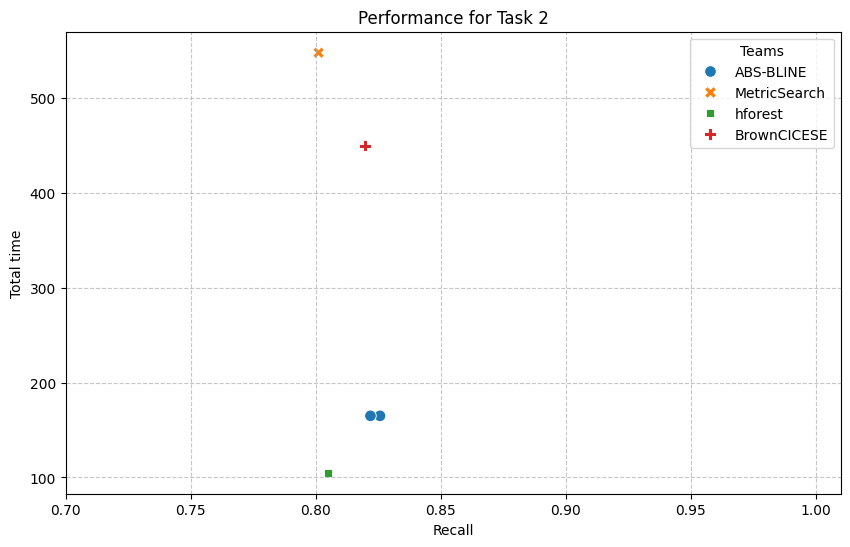

In [6]:
plt.figure(figsize=(10, 6))
#task1 = df[df.task == 'task1']
task2 = df.query("task == 'task2' and total_time <= 12 * 60 * 60")

display(task2)
sns.scatterplot(x='recall', y='total_time', hue='team', style='team', markers=True, s=70, data=task2)

plt.title('Performance for Task 2')
plt.xlabel('Recall')
plt.ylabel('Total time') 
plt.xlim(((0.7, 1.01)))
plt.legend(title='Teams')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("fig-task2.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
task2 = df.query("task == 'task2'")

R = {
    'team': [],
    'k': [],
    'recall': [],
    'buildtime': [],
    'querytime': [],
    #'throughput': [],
    'total_time': [],
    'params': [],
}

for name, g in task2.groupby(by='team'):
    if len(g.team) == 0:
        continue
    
    G = g.iloc[0]
    R['team'].append(G.team)
    R['k'].append(G.k)
    R['recall'].append(G.recall)
    R['buildtime'].append(G.buildtime)
    R['querytime'].append(G.querytime)
    #R['throughput'].append(G.throughput)
    R['params'].append(G.params)
    R['total_time'].append(G.total_time)

R = pd.DataFrame(R)
#print(R.to_latex(float_format="%.4f"))
L = R.to_latex(index=False, formatters={
    "recall": lambda x: f"{x:.4f}",
    "buildtime": lambda x: f"{x:.0f}s",
    "querytime": lambda x: f"{x:.0f}s",
    "total_time": lambda x: f"{x:.0f}s",
    "throughput": lambda x: f"{x:.0f} q/s",
    })

display(R)
print(L)


,team,k,recall,buildtime,querytime,total_time,params
0,ABS-BLINE,15,0.825743,8.331754e+01,29.392259,165.0,pca-i8 160; MinRecall 0.9 ; Neighborhood{SatNe...
1,BrownCICESE,15,0.819839,9.080475e+00,437.450753,450.0,"index=(BrownCICESE),query=(M=52,H=26,O=100000,..."
2,DCC-UChile,15,0.543154,2.331547e+02,112970.109062,113213.0,"root_join_params: 1,1; PCA params: 0.8"
3,JLapeyra,15,0.994429,1.000000e+09,61430.494061,61433.0,"{""d_pca"": 140, ""k_search"": 200, ""no_self_loops..."
4,MetricSearch,15,0.801161,5.420000e+02,528.000000,548.0,NaN
5,hforest,15,0.804859,0.000000e+00,98.904733,105.0,"index=(ntrees=80,leaf_size=10),query=(ntrees=8..."


\begin{tabular}{lrrrrrl}
\toprule
team & k & recall & buildtime & querytime & total_time & params \\
\midrule
ABS-BLINE & 15 & 0.8257 & 83s & 29s & 165s & pca-i8 160; MinRecall 0.9 ; Neighborhood{SatNeighborhood} logbase 1.3 minsize Int32 2 filter SatNeighborhood \\
BrownCICESE & 15 & 0.8198 & 9s & 437s & 450s & index=(BrownCICESE),query=(M=52,H=26,O=100000,I=1) \\
DCC-UChile & 15 & 0.5432 & 233s & 112970s & 113213s & root_join_params: 1,1; PCA params: 0.8 \\
JLapeyra & 15 & 0.9944 & 1000000000s & 61430s & 61433s & {"d_pca": 140, "k_search": 200, "no_self_loops": false} \\
MetricSearch & 15 & 0.8012 & 542s & 528s & 548s & NaN \\
hforest & 15 & 0.8049 & 0s & 99s & 105s & index=(ntrees=80,leaf_size=10),query=(ntrees=80,even=96,odd=97,dist=60,hops=0) \\
\bottomrule
\end{tabular}

